In [3]:
import notebook_setup
import matplotlib.pyplot as plt
import numpy as np
import json

from src.plot_style import set_plot_style

set_plot_style()

c:\Users\maria\PhD\quantum_trajectories\monitored-quantum-systems
c:\Users\maria\PhD\quantum_trajectories\monitored-quantum-systems


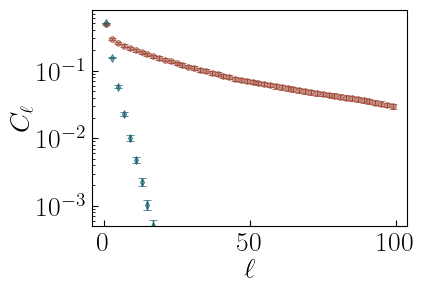

In [12]:
gradient_teal_1 = ["#E4F3F6","#B8E0E7","#82C9D6","#4FB2C6","#2C9CB5","#1F7F95","#166370"]
gradient_teal_03 = [(228/255, 243/255, 246/255, 0.5),(184/255, 224/255, 231/255, 0.5),(100/255, 201/255, 214/255, 0.5),(79/255, 178/255, 198/255, 0.5),(44/255, 156/255, 181/255, 0.5),(31/255, 127/255, 149/255, 0.5),(22/255, 99/255, 112/255, 0.5)]
gradient_orange_1 = ["#FBE9E3","#F6CFC3","#F0B2A0","#EA937D","#E37259","#C85D47","#9F4736"]
gradient_orange_03 = [(251/255, 233/255, 227/255, 0.5),(246/255, 207/255, 195/255, 0.5),(240/255, 178/255, 160/255, 0.5),(234/255, 147/255, 125/255, 0.5),(227/255, 114/255, 89/255, 0.5),(200/255, 93/255, 71/255, 0.5),(159/255, 71/255, 54/255, 0.5),]

def cm_to_inch(cm):
    return cm / 2.54

panel_width_cm = 8.0
panel_height_cm = 5.5
margin_cm = 2.0

fig_width = cm_to_inch(panel_width_cm + 2 * margin_cm)
fig_height = cm_to_inch(panel_height_cm + 2 * margin_cm)

fig = plt.figure(figsize=(fig_width, fig_height))

left = margin_cm / (panel_width_cm + 2 * margin_cm)
bottom = margin_cm / (panel_height_cm + 2 * margin_cm)
width = panel_width_cm / (panel_width_cm + 2 * margin_cm)
height = panel_height_cm / (panel_height_cm + 2 * margin_cm)

ax = fig.add_axes([left, bottom, width, height])
step = 2 
x = np.arange(1, 100 + 1)
V_values = [5.875, 2.000]
for V in V_values:
    if V == 2.000:
        colors1 = gradient_teal_1
        colors03 = gradient_teal_03
    else:
        colors1 = gradient_orange_1
        colors03 = gradient_orange_03        
    marker = 'o' if V == 5.875 else 'd'
    import os
    print(os.getcwd())
    correlations3_mean = np.load(f'figures_data/correlations_central_spins_V_{V:.3f}_num_sites_{20}.npy')
    correlations3_err = np.load(f'figures_data/errors_central_spins_V_{V:.3f}_num_sites_{20}.npy')
    ax.errorbar(x[::step],correlations3_mean[::step],yerr=correlations3_err[::step],fmt='none',capsize=3.0,color=colors1[-1],linewidth=1,capthick=0.5,zorder=1)
    ax.plot(x[::step],correlations3_mean[::step],marker=marker,markersize=4.0,linestyle='None',markerfacecolor=colors03[-1],markeredgecolor=colors1[-1],markeredgewidth=0.5,label=fr"$V = {V:.3f}$")

ax.set_ylabel(r"$C_\ell$", fontsize=20, labelpad=2.0)    
ax.set_xlabel(r"$\ell$", fontsize=20, labelpad=2.0)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_yscale("log")
ax.set_ylim(bottom=1e-3/2, top=1e-1*8)
plt.savefig("figures/svg/fig4_a.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig4_a.pdf", dpi=300, transparent=True)

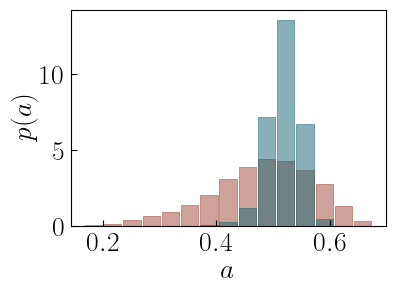

In [11]:
def cm_to_inch(cm):
    return cm / 2.54

panel_width_cm = 8.0
panel_height_cm = 5.5
margin_cm = 2.0

fig_width = cm_to_inch(panel_width_cm + 2 * margin_cm)
fig_height = cm_to_inch(panel_height_cm + 2 * margin_cm)

fig = plt.figure(figsize=(fig_width, fig_height))

left = margin_cm / (panel_width_cm + 2 * margin_cm)
bottom = margin_cm / (panel_height_cm + 2 * margin_cm)
width = panel_width_cm / (panel_width_cm + 2 * margin_cm)
height = panel_height_cm / (panel_height_cm + 2 * margin_cm)

ax = fig.add_axes([left, bottom, width, height]) 

gradient_teal_1 = ["#E4F3F6","#B8E0E7","#82C9D6","#4FB2C6","#2C9CB5","#1F7F95","#166370"]
gradient_teal_03 = [(228/255, 243/255, 246/255, 0.5),(184/255, 224/255, 231/255, 0.5),(100/255, 201/255, 214/255, 0.5),(79/255, 178/255, 198/255, 0.5),(44/255, 156/255, 181/255, 0.5),(31/255, 127/255, 149/255, 0.5),(22/255, 99/255, 112/255, 0.5)]
gradient_orange_1 = ["#FBE9E3","#F6CFC3","#F0B2A0","#EA937D","#E37259","#C85D47","#9F4736"]
gradient_orange_03 = [(251/255, 233/255, 227/255, 0.5),(246/255, 207/255, 195/255, 0.5),(240/255, 178/255, 160/255, 0.5),(234/255, 147/255, 125/255, 0.5),(227/255, 114/255, 89/255, 0.5),(200/255, 93/255, 71/255, 0.5),(159/255, 71/255, 54/255, 0.5),]

with open("figures_data/activity_histogram_data.json") as f:
    data = json.load(f)

num_bins = data["num_bins_default"]
datasets = data["data"]

all_a = np.concatenate([
    np.repeat(d["activities"], d["counts"])
    for d in datasets.values()
])

bins = np.linspace(all_a.min(), all_a.max(), num_bins + 1)
bin_width = bins[1] - bins[0]

colors = {
    "V_2.000": (22/255, 99/255, 112/255, 0.5),
    "V_5.875": (159/255, 71/255, 54/255, 0.5),
}
dark_colors = {
    "V_2.000": "#166370",
    "V_5.875": "#9F4736",
}

for key, d in datasets.items():
    a = np.array(d["activities"])
    w = np.array(d["counts"]) / np.sum(d["counts"])

    hist, edges = np.histogram(a, bins=bins, weights=w, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.bar(centers, hist, width=0.9 * bin_width,
            color=colors[key],
            edgecolor=colors[key], linewidth=0.7,
            label=key.replace("_", "="))

plt.xlabel(r"$a$", fontsize=20, labelpad=2.0)
plt.ylabel(r"$p(a)$", fontsize=20, labelpad=2.0)
plt.xticks([0.2, 0.4, 0.6], fontsize=20)
plt.yticks([0, 5, 10], fontsize=20)

plt.savefig("figures/svg/fig4_b.svg", dpi=300, transparent=True)
plt.savefig("figures/pdf/fig4_b.pdf", dpi=300, transparent=True)
plt.show()